In [1]:
from pathlib import Path

PROJECT_ROOT = Path("..")
MODEL_RESULTS = PROJECT_ROOT / "model_results"
GENERATED_RESULTS = PROJECT_ROOT / "generated_results"
GENERATED_RESULTS.mkdir(exist_ok=True)

In [2]:
# Auto-discover classifiers and common datasets from disk
classifiers = sorted(p.name for p in MODEL_RESULTS.iterdir() if p.is_dir())
print("Classifiers found:", classifiers)

# dataset_sets = [
#     set(p.name for p in (MODEL_RESULTS / c / "Predictions").iterdir() if p.is_dir())
#     for c in classifiers
# ]
# datasets = sorted(set.intersection(*dataset_sets))
from aeon.datasets.tsc_datasets import univariate_equal_length

datasets = univariate_equal_length
print(f"Common datasets: {len(datasets)}")

# Detect available resamples from any classifier/dataset combo
sample_files = list((MODEL_RESULTS / classifiers[0] / "Predictions" / datasets[0]).glob("testResample*.csv"))
resamples = sorted(int(f.stem.replace("testResample", "")) for f in sample_files)
# resamples = [1]
print(f"Resamples: {resamples}")

Classifiers found: ['Catch22', 'HIVECOTEV2', 'MiniRocket', 'MultiRocketHydra', 'ROCKET', 'TSCGlue-Accuracy-GPU', 'TSCGlue-LogLoss-GPU', 'TSCGlue-ROCAUC-GPU', 'TSCGlueDual-LogLoss-GPU', 'TSCGlueET-GPU', 'TSCGlueETAll-GPU', 'TSCGlueETAllV2-GPU', 'TSCGlueEnhanced-High-LogLoss-GPU', 'TSCGlueEnhanced-Low-LogLoss-GPU', 'TSCGlueEnhanced-Medium-LogLoss-GPU', 'TSCGlueEnhancedV2-High-Accuracy-GPU', 'TSCGlueEnhancedV2-High-F1-GPU', 'TSCGlueEnhancedV2-High-LogLoss-GPU', 'TSCGlueEnhancedV2-High-ROCAUC-GPU', 'TSCGlueEnhancedV2-Low-Accuracy-GPU', 'TSCGlueEnhancedV2-Low-F1-GPU', 'TSCGlueEnhancedV2-Low-LogLoss-GPU', 'TSCGlueEnhancedV2-Low-ROCAUC-GPU', 'TSCGlueEnhancedV2-Medium-Accuracy-GPU', 'TSCGlueEnhancedV2-Medium-F1-GPU', 'TSCGlueEnhancedV2-Medium-LogLoss-GPU', 'TSCGlueEnhancedV2-Medium-ROCAUC-GPU', 'TSCGlueMean-GPU', 'TSCGlueMeanBalanced-GPU', 'TSCGlueMeanV2-GPU', 'TSCGlueRidgeAll-GPU', 'TSCGlueWeaselV2-Accuracy-GPU', 'TSCGlueWeaselV2-LogLoss-GPU', 'TSCGlueWeaselV2-ROCAUC-GPU', 'f-AllFeaturesET', 

In [3]:
classifiers.remove('f-MRHydraLogistic')
# classifiers.remove('TSCGlueRidgeAll-GPU')


# Count missing combinations (classifier x dataset x resample)
total = len(classifiers) * len(datasets) * len(resamples)
print(total, len(classifiers), len(datasets), len(resamples))
missing = 0
missing_list = []
for c in classifiers:
    for d in datasets:
        for r in resamples:
            path = MODEL_RESULTS / c / "Predictions" / d / f"testResample{r}.csv"
            if not path.exists():
                missing += 1
                missing_list.append((c, d, r))

print(f"Total combinations : {total}")
print(f"Present            : {total - missing}")
print(f"Missing            : {missing}")

per_model = len(datasets) * len(resamples)
print(f"\nMissing per model (out of {per_model}):")
for c in classifiers:
    n = sum(1 for mc, _, _ in missing_list if mc == c)
    if n:
        print(f"  {c:<35} {n}")

if missing_list:
    print("\nFirst 40 missing:")
    for c, d, r in missing_list[:40]:
        print(f"  {c} / {d} / resample {r}")

13776 41 112 3
Total combinations : 13776
Present            : 13776
Missing            : 0

Missing per model (out of 336):


In [ ]:
from tsml_eval.evaluation import evaluate_classifiers_by_problem

evaluate_classifiers_by_problem(
    str(MODEL_RESULTS),
    classifiers,
    datasets,
    str(GENERATED_RESULTS),
    resamples=resamples,
    error_on_missing=False,
    eval_name="tscbench",
    verbose=True,
    continue_on_missing=False,
)

Loaded Catch22 on ACSF1 test resample 0.
Loaded Catch22 on ACSF1 test resample 1.
Loaded Catch22 on ACSF1 test resample 4.
Loaded Catch22 on Adiac test resample 0.
Loaded Catch22 on Adiac test resample 1.
Loaded Catch22 on Adiac test resample 4.
Loaded Catch22 on ArrowHead test resample 0.
Loaded Catch22 on ArrowHead test resample 1.
Loaded Catch22 on ArrowHead test resample 4.
Loaded Catch22 on Beef test resample 0.
Loaded Catch22 on Beef test resample 1.
Loaded Catch22 on Beef test resample 4.
Loaded Catch22 on BeetleFly test resample 0.
Loaded Catch22 on BeetleFly test resample 1.
Loaded Catch22 on BeetleFly test resample 4.
Loaded Catch22 on BirdChicken test resample 0.
Loaded Catch22 on BirdChicken test resample 1.
Loaded Catch22 on BirdChicken test resample 4.
Loaded Catch22 on BME test resample 0.
Loaded Catch22 on BME test resample 1.
Loaded Catch22 on BME test resample 4.
Loaded Catch22 on Car test resample 0.
Loaded Catch22 on Car test resample 1.
Loaded Catch22 on Car test r

/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/tsml_eval/evaluation/multiple_estimator_evaluation.py:1209: UserWarning: Number of jobs for HIVECOTEV2 on ACSF1 test resample 0 is 8, which is different to the first result with 4. This may cause inconsistencies in timing results.
  warnings.warn(
/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/tsml_eval/evaluation/multiple_estimator_evaluation.py:1209: UserWarning: Number of jobs for HIVECOTEV2 on ACSF1 test resample 1 is 8, which is different to the first result with 4. This may cause inconsistencies in timing results.
  warnings.warn(
/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/tsml_eval/evaluation/multiple_estimator_evaluation.py:1209: UserWarning: Number of jobs for HIVECOTEV2 on Adiac test resample 0 is 8, which is different to the first result with 4. This may cause inconsistencies in timing results.
  warnings.warn(
/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-p

In [ ]:
# Display all generated figures inline
from IPython.display import display, Image

for fig_path in sorted(GENERATED_RESULTS.rglob("*.pdf")):
    print(fig_path.relative_to(PROJECT_ROOT))

for fig_path in sorted(GENERATED_RESULTS.rglob("*.png")):
    print(fig_path.relative_to(PROJECT_ROOT))
    display(Image(filename=str(fig_path)))

generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_HIVECOTEV2.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_MiniRocket.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_MultiRocketHydra.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_ROCKET.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_TSCGlue-Accuracy-GPU.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_TSCGlue-LogLoss-GPU.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_TSCGlue-ROCAUC-GPU.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_TSCGlueDual-LogLoss-GPU.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_TSCGlueET-GPU.pdf
generated_results/t

In [ ]:
import pandas as pd

for csv_path in sorted(GENERATED_RESULTS.glob("**/*summary*.csv")):
    print(csv_path.name)
    display(pd.read_csv(csv_path, index_col=0))

tscbench_summary.csv


,TSCGlueMeanBalanced-GPU,TSCGlueEnhancedV2-High-Accuracy-GPU,TSCGlueEnhancedV2-High-F1-GPU,TSCGlueEnhancedV2-High-ROCAUC-GPU,TSCGlueEnhanced-Medium-LogLoss-GPU,TSCGlueEnhancedV2-Medium-Accuracy-GPU,TSCGlueEnhancedV2-Medium-F1-GPU,TSCGlueEnhancedV2-Medium-ROCAUC-GPU,TSCGlueMean-GPU,TSCGlueMeanV2-GPU,...,TSCGlueEnhancedV2-Low-F1-GPU,MultiRocketHydra,f-AllFeaturesET,f-MultiET,MiniRocket,ROCKET,f-ShapeDictET,f-MRHydraET,f-QuantET,Catch22
testAccuracy,,,,,,,,,,,,,,,,,,,,,
testAccuracyMean,0.8916349950755558,0.8912527580852769,0.8912527580852769,0.8912527580852769,0.8904639323299198,0.8904639323299198,0.8904639323299198,0.8904639323299198,0.8911676820577348,0.8907325510108336,...,0.8845019332230865,0.879590211636902,0.874439246118315,0.8742013569492999,0.8704104319564149,0.8652259217340242,0.867308668711299,0.8651601313743368,0.8565445964238189,0.7898663887869705
testAccuracyAvgRank,14.96875,15.022321428571429,15.022321428571429,15.022321428571429,15.133928571428571,15.133928571428571,15.133928571428571,15.133928571428571,15.191964285714286,15.254464285714286,...,23.040178571428573,25.517857142857142,28.642857142857142,28.660714285714285,28.946428571428573,29.397321428571427,30.191964285714285,32.120535714285715,32.1875,39.07142857142857
testBalAcc,TSCGlueMeanBalanced-GPU,TSCGlueEnhancedV2-High-Accuracy-GPU,TSCGlueEnhancedV2-High-F1-GPU,TSCGlueEnhancedV2-High-ROCAUC-GPU,TSCGlueMean-GPU,TSCGlueEnhanced-Medium-LogLoss-GPU,TSCGlueEnhancedV2-Medium-Accuracy-GPU,TSCGlueEnhancedV2-Medium-F1-GPU,TSCGlueEnhancedV2-Medium-ROCAUC-GPU,TSCGlueMeanV2-GPU,...,HIVECOTEV2,MultiRocketHydra,MiniRocket,ROCKET,f-AllFeaturesET,f-MultiET,f-ShapeDictET,f-QuantET,f-MRHydraET,Catch22
testBalAccMean,0.8758799320415784,0.8747474150401163,0.8747474150401163,0.8747474150401163,0.8736623830504952,0.8719378849635622,0.8719378849635622,0.8719378849635622,0.8719378849635622,0.8724505025047983,...,0.864232946815468,0.8607821451325339,0.8507807050518469,0.8460310561029329,0.8509885297142746,0.8509590271347144,0.8423366298329725,0.8327272812166095,0.84138535134211,0.7645123394605704
testBalAccAvgRank,13.34375,13.549107142857142,13.549107142857142,13.549107142857142,15.151785714285714,15.361607142857142,15.361607142857142,15.361607142857142,15.361607142857142,15.5,...,23.705357142857142,25.647321428571427,29.357142857142858,29.428571428571427,29.638392857142858,29.736607142857142,31.071428571428573,32.839285714285715,33.191964285714285,39.00892857142857
testAUROC,TSCGlueMeanV2-GPU,TSCGlueEnhancedV2-High-Accuracy-GPU,TSCGlueEnhancedV2-High-F1-GPU,TSCGlueEnhancedV2-High-ROCAUC-GPU,TSCGlueMean-GPU,TSCGlueMeanBalanced-GPU,TSCGlueEnhanced-Medium-LogLoss-GPU,TSCGlueEnhancedV2-Medium-Accuracy-GPU,TSCGlueEnhancedV2-Medium-F1-GPU,TSCGlueEnhancedV2-Medium-ROCAUC-GPU,...,TSCGlueET-GPU,f-QuantET,TSCGlue-Accuracy-GPU,TSCGlueEnhancedV2-Low-Accuracy-GPU,TSCGlueWeaselV2-Accuracy-GPU,Catch22,TSCGlueRidgeAll-GPU,MultiRocketHydra,MiniRocket,ROCKET
testAUROCMean,0.966681606419413,0.9669301059516575,0.9669301059516575,0.9669301059516575,0.9622729231006198,0.9624781951137792,0.9657216431881464,0.9657216431881464,0.9657216431881464,0.9657216431881464,...,0.9539659484647206,0.9570234967203105,0.9219583616417862,0.925907494580555,0.9234757301041839,0.926045159967653,0.9160140070297572,0.9097153362080376,0.902736996017229,0.8998932466177015
testAUROCAvgRank,10.915178571428571,10.933035714285714,10.933035714285714,10.933035714285714,11.977678571428571,11.995535714285714,12.620535714285714,12.620535714285714,12.620535714285714,12.620535714285714,...,25.848214285714285,26.4375,33.39732142857143,33.45982142857143,33.776785714285715,34.69642857142857,35.22767857142857,36.46875,37.79017857142857,38.107142857142854
testLogLoss,TSCGlueEnhancedV2-High-LogLoss-GPU,TSCGlueETAllV2-GPU,TSCGlueEnhanced-High-LogLoss-GPU,TSCGlueDual-LogLoss-GPU,TSCGlueMeanV2-GPU,TSCGlueEnhancedV2-Medium-LogLoss-GPU,TSCGlueETAll-GPU,TSCGlueMean-GPU,TSCGlueWeaselV2-ROCAUC-GPU,TSCGlueWeaselV2-LogLoss-GPU,...,TSCGlueEnhancedV2-Low

tscbench_summary_table.csv


,Catch22,HIVECOTEV2,MiniRocket,MultiRocketHydra,ROCKET,TSCGlue-Accuracy-GPU,TSCGlue-LogLoss-GPU,TSCGlue-ROCAUC-GPU,TSCGlueDual-LogLoss-GPU,TSCGlueET-GPU,...,TSCGlueWeaselV2-Accuracy-GPU,TSCGlueWeaselV2-LogLoss-GPU,TSCGlueWeaselV2-ROCAUC-GPU,f-AllFeaturesET,f-AllFeaturesRidge,f-MRHydraET,f-MRHydraRidge,f-MultiET,f-QuantET,f-ShapeDictET
testAccuracyMean,7.898664e-01,8.860845e-01,8.704104e-01,8.795902e-01,8.652259e-01,8.886901e-01,8.866986e-01,8.865734e-01,8.900380e-01,8.837246e-01,...,8.903294e-01,8.893038e-01,8.892962e-01,8.744392e-01,8.886376e-01,8.651601e-01,8.862402e-01,8.742014e-01,8.565446e-01,8.673087e-01
testBalAccMean,7.645123e-01,8.642329e-01,8.507807e-01,8.607821e-01,8.460311e-01,8.688058e-01,8.678572e-01,8.675592e-01,8.720052e-01,8.665771e-01,...,8.703960e-01,8.706566e-01,8.706493e-01,8.509885e-01,8.685583e-01,8.413854e-01,8.669014e-01,8.509590e-01,8.327273e-01,8.423366e-01
testAUROCMean,9.260452e-01,9.647423e-01,9.027370e-01,9.097153e-01,8.998932e-01,9.219584e-01,9.592585e-01,9.594155e-01,9.619522e-01,9.539659e-01,...,9.234757e-01,9.603910e-01,9.603915e-01,9.623809e-01,9.606117e-01,9.582891e-01,9.590101e-01,9.624000e-01,9.570235e-01,9.589299e-01
testLogLossMean,6.706969e-01,3.766384e-01,4.670881e+00,4.340009e+00,4.857750e+00,3.601803e+00,7.154207e-01,7.159851e-01,7.061973e-01,8.394149e-01,...,3.542480e+00,7.109796e-01,7.109796e-01,4.558510e-01,7.999735e-01,4.786249e-01,8.083606e-01,4.538865e-01,5.119941e-01,5.075544e-01
testSensitivityMean,7.726923e-01,8.672606e-01,8.560132e-01,8.657150e-01,8.507658e-01,8.723421e-01,8.760752e-01,8.759027e-01,8.783239e-01,8.733674e-01,...,8.746542e-01,8.784496e-01,8.784420e-01,8.565887e-01,8.725720e-01,8.470069e-01,8.716841e-01,8.562913e-01,8.394471e-01,8.480804e-01
testSpecificityMean,7.975222e-01,8.963779e-01,8.782306e-01,8.867604e-01,8.726191e-01,8.975768e-01,8.918046e-01,8.917419e-01,8.958048e-01,8.885465e-01,...,8.987145e-01,8.947099e-01,8.947023e-01,8.839994e-01,8.975350e-01,8.747011e-01,8.939090e-01,8.838571e-01,8.651194e-01,8.778553e-01
testF1Mean,7.665398e-01,8.677692e-01,8.555425e-01,8.652299e-01,8.498247e-01,8.702111e-01,8.730461e-01,8.731118e-01,8.759357e-01,8.703980e-01,...,8.723247e-01,8.760524e-01,8.760448e-01,8.552982e-01,8.730818e-01,8.454717e-01,8.717224e-01,8.548783e-01,8.366329e-01,8.466442e-01
testFitTimeMean,1.372220e+03,9.455479e+06,3.029735e+03,6.312557e+03,5.123923e+03,9.155971e+04,9.709645e+04,9.436193e+04,2.925489e+05,1.787210e+05,...,1.610488e+05,1.587485e+05,1.688300e+05,4.280461e+04,5.522668e+04,7.244557e+03,1.564454e+04,1.841721e+04,1.594131e+03,3.037505e+04
testPredictTimeMean,1.200378e+03,5.004031e+06,1.916399e+02,4.339658e+03,5.920449e+03,7.079259e+04,7.290587e+04,7.114783e+04,2.236300e+05,1.110943e+05,...,1.408556e+05,1.411900e+05,1.425060e+05,5.879548e+04,6.985596e+04,8.176714e+03,1.316809e+04,1.817274e+04,1.340286e+03,3.425841e+04
testMemoryUsageMean,8.290584e+06,8.277351e+08,5.537813e+07,4.344606e+08,9.655762e+07,2.054227e+08,1.934240e+08,1.892027e+08,2.245094e+08,1.457144e+08,...,2.044449e+08,2.179012e+08,2.066084e+08,7.818187e+08,1.452561e+09,5.380510e+08,7.866666e+08,1.597636e+08,1.424049e+07,3.392366e+08


Accuracy: 112 datasets


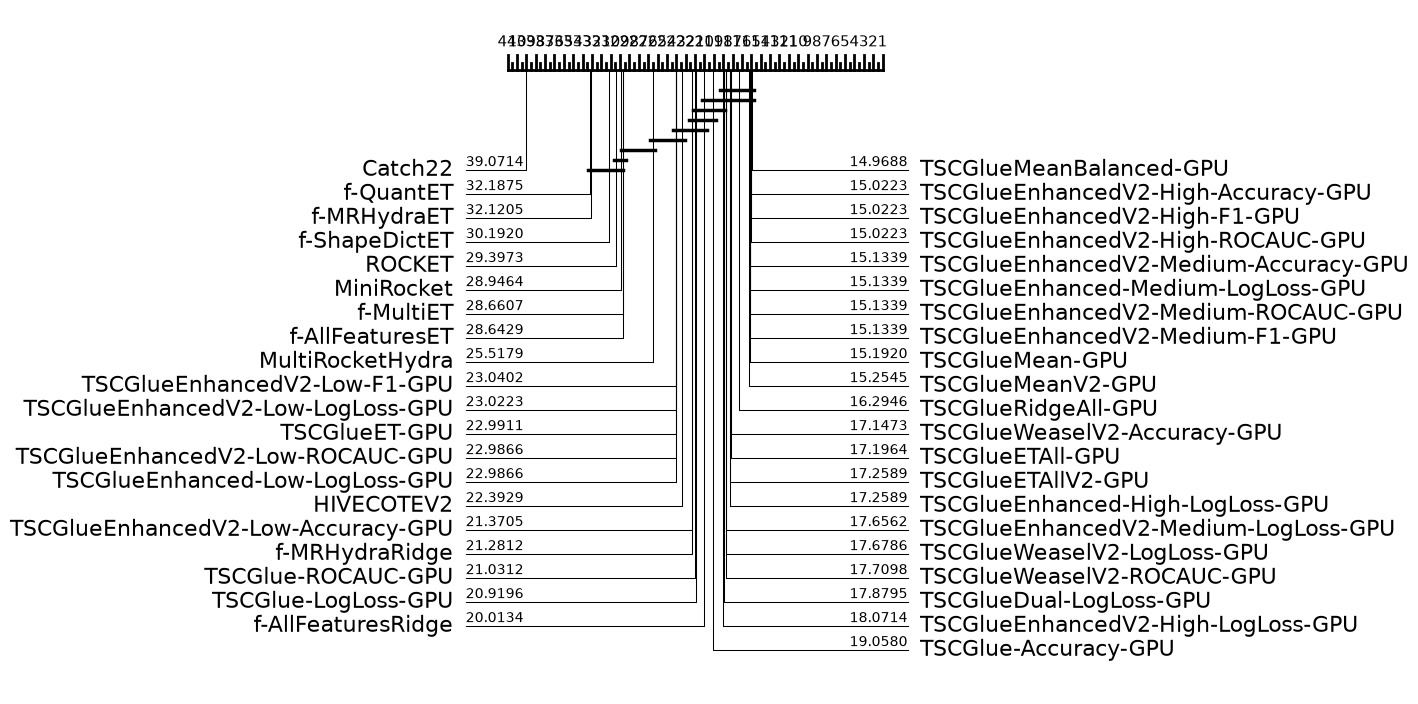

LogLoss: 112 datasets


/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


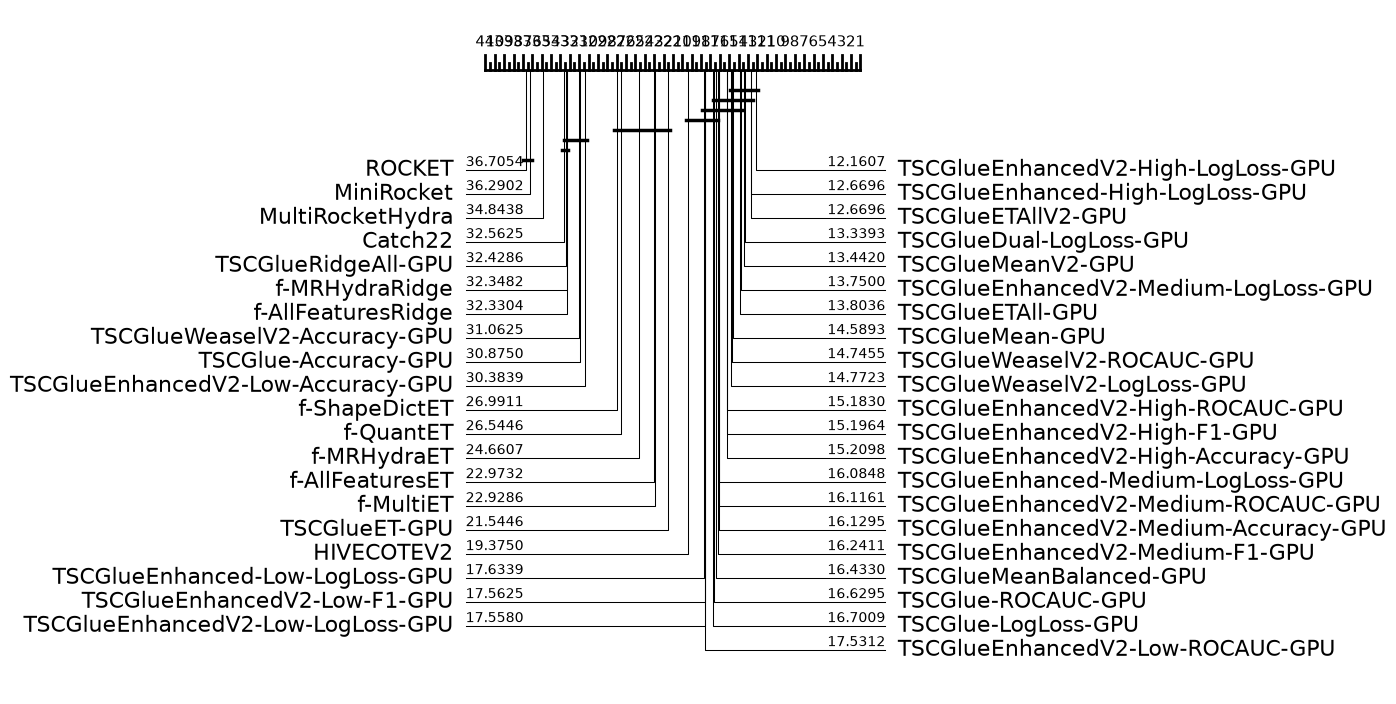

F1: 112 datasets


/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


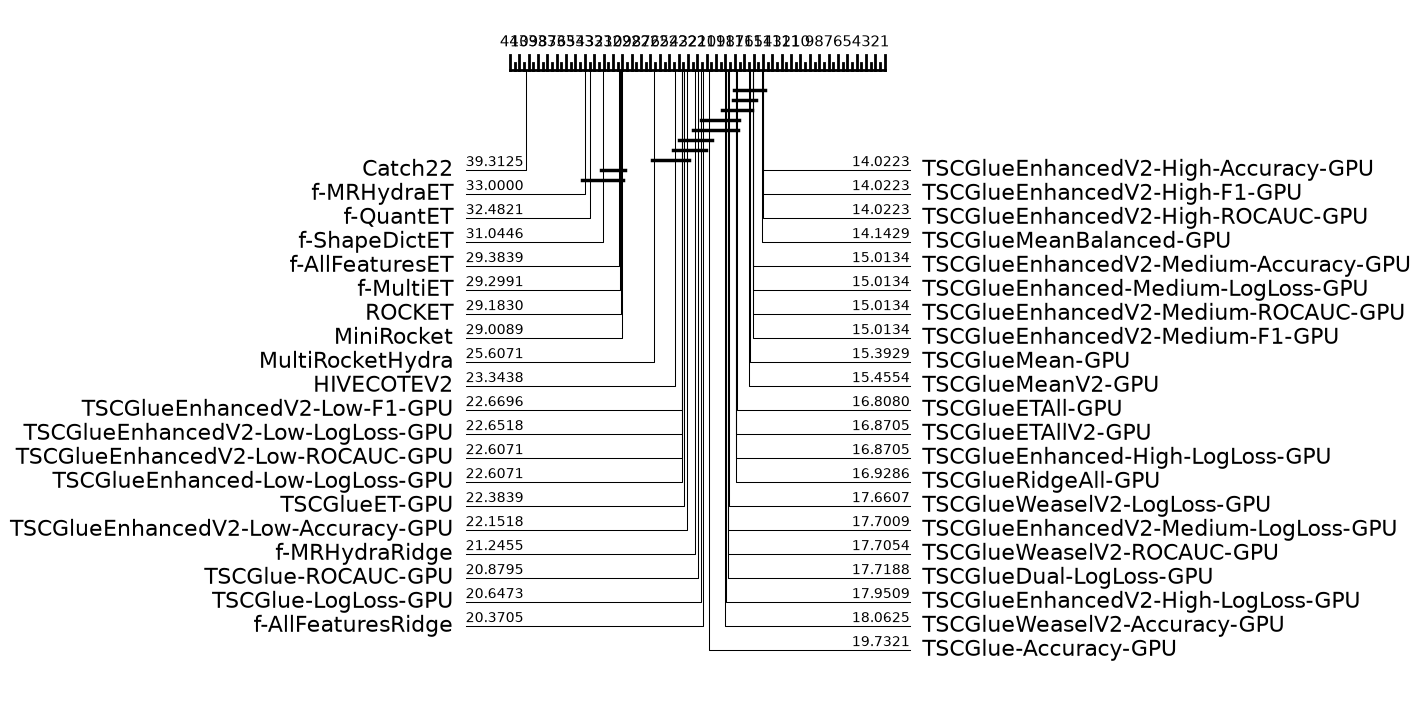

ROCAUC: 112 datasets


/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


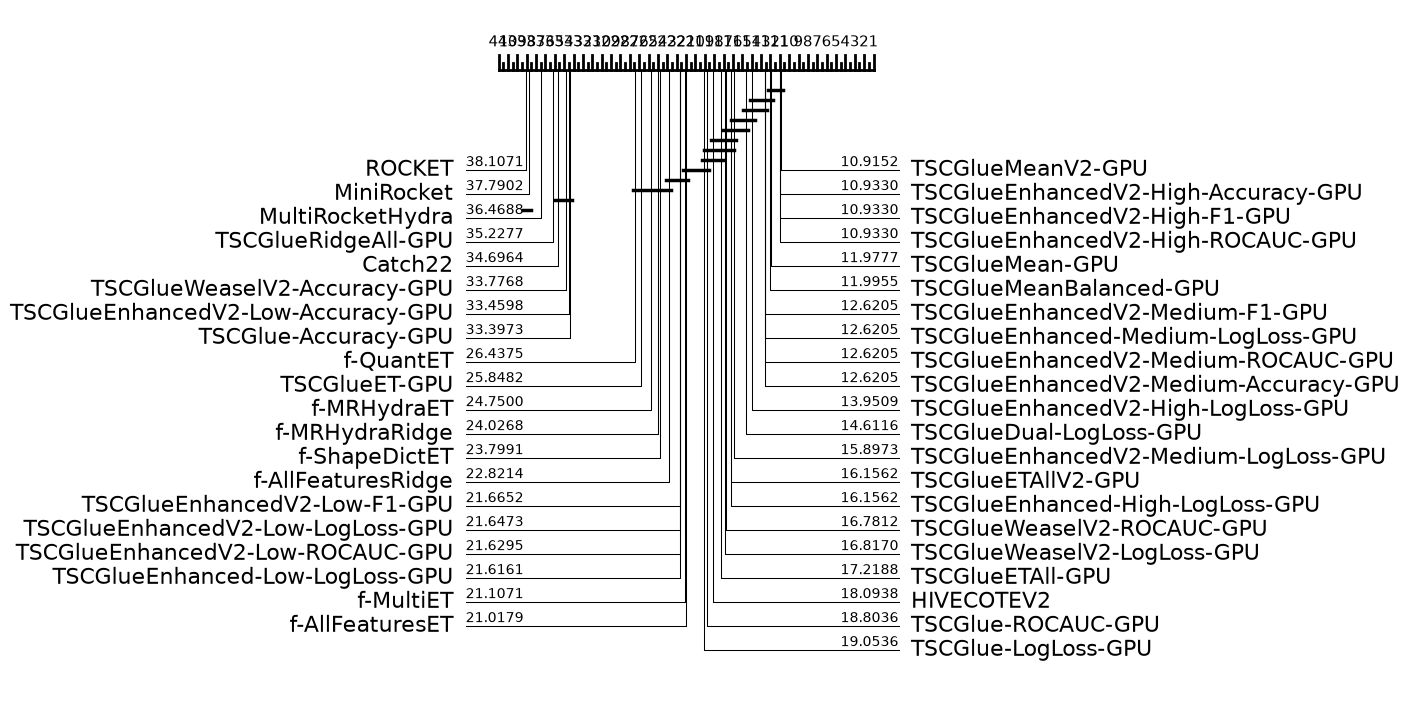

In [ ]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd

for label, subdir, metric in [
    ("Accuracy", "Accuracy", "accuracy"),
    ("LogLoss", "LogLoss", "logloss"),
    ("F1", "F1", "f1"),
    ("ROCAUC", "AUROC", "auroc"),
]:
    fig_dir = GENERATED_RESULTS / "tscbench" / subdir
    pkl_path = fig_dir / "figures" / f"tscbench_{metric}_critical_difference.pickle"
    ranks_path = fig_dir / f"{metric}_ranks.csv"

    if not pkl_path.exists():
        print(f"{label}: no figure found at {pkl_path} (evaluate_classifiers_by_problem "
              "may have skipped it — check for missing results above)")
        continue

    n_datasets = pd.read_csv(ranks_path, index_col=0).dropna().shape[0]
    print(f"{label}: {n_datasets} datasets")

    with open(pkl_path, "rb") as f:
        fig = pickle.load(f)
    display(fig)
    plt.close(fig)